<a href="https://colab.research.google.com/github/ladparag100/AI-Projects/blob/main/Multi_Agent_Travel_Planner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travel Planning Multi-Agent system**

An intelligent system that coordinates multiple specialized agents to search flights, hotels, plan itineraries, and provide personalized travel recommendations.

# **Step 1 - Start with the process to automate**


*   Search hotels and flights based on user preferences

*   Plan complete travel itineraries


*   Answer travel-related questions with deep research

*   Handle multiple queries in parallel


*   Present unified, well-formatted travel recommendation










# **Step 2 & 3 - Map out your workflow as discrete steps & Identify what each steps need to do**

*   **Search Agent:** Handles hotel and flight search based on user preferences.

*  **Itinerary Planner Agent:** Utilizes search results and research to create detailed travel plans.


## Install LangGraph

In [ ]:
# from openai import OpenAI
# client = OpenAI()

# response = client.responses.create(
#     model="gpt-5.5",
#     input="Write a short bedtime story about a unicorn."
# )

# print(response)

In [ ]:
!pip install -U -q langgraph langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.1/114.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.5 MB/s eta 0:00:00


## Chat Model

In [ ]:
# Install Required Libraries
!pip install -U -q langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.6 MB/s eta 0:00:00


In [ ]:
# Import API Keys

import getpass
import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

In [ ]:
# Chat Model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5.2",
    # stream_usage=True,
    temperature=0.2,
)

### Test Chat Model

In [ ]:
test_msg = llm.invoke("What is Machine Learning? Explain with the help of an example.") #stream

In [ ]:
test_msg

AIMessage(content='Machine Learning (ML) is a branch of Artificial Intelligence where a computer system learns patterns from data and uses those patterns to make predictions or decisions—without being explicitly programmed with fixed rules for every situation.\n\n### Key idea\nInstead of writing rules like “IF this happens, THEN do that,” you give the system examples (data), and it learns a model (a mathematical pattern) that generalizes to new, unseen cases.\n\n---\n\n## Example: Email Spam Detection\n**Goal:** Decide whether a new email is *Spam* or *Not Spam*.\n\n### 1) Training data (examples)\nYou collect many emails that are already labeled:\n\n- Email A: “Win a free iPhone now!” → **Spam**\n- Email B: “Meeting agenda for tomorrow” → **Not Spam**\n- Email C: “Claim your prize, click here” → **Spam**\n- Email D: “Invoice for your purchase” → **Not Spam**\n\n### 2) Learning patterns\nThe ML algorithm learns that certain features (patterns) often appear in spam, such as:\n- Words li

In [ ]:
# Print in Readable Format
print(test_msg.content)

Machine Learning (ML) is a branch of Artificial Intelligence where a computer system learns patterns from data and uses those patterns to make predictions or decisions—without being explicitly programmed with fixed rules for every situation.

### Key idea
Instead of writing rules like “IF this happens, THEN do that,” you give the system examples (data), and it learns a model (a mathematical pattern) that generalizes to new, unseen cases.

---

## Example: Email Spam Detection
**Goal:** Decide whether a new email is *Spam* or *Not Spam*.

### 1) Training data (examples)
You collect many emails that are already labeled:

- Email A: “Win a free iPhone now!” → **Spam**
- Email B: “Meeting agenda for tomorrow” → **Not Spam**
- Email C: “Claim your prize, click here” → **Spam**
- Email D: “Invoice for your purchase” → **Not Spam**

### 2) Learning patterns
The ML algorithm learns that certain features (patterns) often appear in spam, such as:
- Words like “free,” “win,” “prize,” “click”
- Ex

## **Itinerary Agent or Scout**

In [ ]:
# Install Required Libraries

!pip install -q deepagents tavily-python langchain-tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.9/197.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.1/763.1 kB 29.9 MB/s eta 0:00:00


### Web Search Tool

In [ ]:
# Necessary Imports

from typing import Literal
from tavily import TavilyClient

In [ ]:
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

In [ ]:
# Import API Keys

try:
    api_key_from_secrets = userdata.get("TAVILY_API_KEY")
    os.environ["TAVILY_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

In [ ]:
# Create Internet Search vis TavilySearch #TOOL

from langchain_tavily import TavilySearch

internet_search = TavilySearch( #internet_search is a tool
    max_results=5,
    topic="general",
    include_images=True,
    include_image_descriptions=True,
    search_depth="advanced",
)

In [ ]:
# Test internet_search tavily
internet_search.invoke({"query": "Top Travel attractions in Vienna"})

### **Deep Research Agent**

In [ ]:
# Define Model for Deep Research Agent - nLATER I WANT TO WRAP THIS IN @TOOL so I CAN USE IT AS A SUBAGENT/TOOL
model = init_chat_model(model="gpt-5.2",
                        model_provider="openai",
                        temperature=0.2)

In [ ]:
# Itinerary Agent (Deep Research) Prompt

from deepagents import create_deep_agent

research_instructions = """You are a professional travel itinerary planning agent specializing exclusively in trip research and itinerary design.

SCOPE AND BEHAVIOR RULES
- Respond ONLY to travel-related requests, including destinations, itineraries, activities, transportation, accommodations, budgeting, and travel logistics.
- If a request is unrelated to travel (e.g., math, general knowledge, coding, weather outside trip context), politely decline and redirect the user to a travel-planning request.
- Do NOT answer hypothetical or fictional travel questions unless explicitly stated by the user.

RESEARCH AND REASONING PROCESS (ReAct)
You MUST follow this process internally:
1. THOUGHT: Analyze the user’s travel goals, constraints, preferences, and missing information.
2. ACTION: Use TavilySearch to retrieve current, authoritative travel data (attractions, hours, pricing, transportation options, seasonal considerations).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty when needed.
4. RESPONSE: Produce a complete, user-ready itinerary.

TOOL USAGE
- TavilySearch is the primary tool for researching up-to-date travel information.
- Prefer official tourism boards, transportation providers, reputable travel guides, and recent reviews.
- Do not fabricate details if information is unavailable; explicitly state assumptions or gaps.

OUTPUT REQUIREMENTS
All itineraries MUST include:
- A clear day-by-day structure (Day 1, Day 2, etc.)
- Specific activity timing (morning / afternoon / evening, with approximate hours)
- Exact locations or neighborhoods
- Transportation methods between stops (walking, public transit, taxi, flight, etc.)
- Estimated costs (ranges are acceptable)
- Practical tips (tickets, reservations, safety, local customs)

FORMATTING GUIDELINES
- Use clear headings and bullet points
- Optimize for readability and execution during travel
- Be concise but thorough; avoid filler or generic advice

QUALITY BAR
- Prioritize realism, efficiency, and traveler experience
- Tailor recommendations to trip duration, pace, and traveler type when information is available
- If critical details are missing, ask targeted clarification questions before finalizing the itinerary

"""

In [ ]:
# Itinerary Agent (deep research agent)
itinerary_research_agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
    tools=[internet_search], #TAVILY
)

In [ ]:
# Test Deep Research Ageent (Itinerary Agent)
result = itinerary_research_agent.invoke({"messages": [{"role": "user",
                                                        "content": "Plan a 5 day travel iternerary for a food & hstorical sites lover in Tanzania"}]})

print(result)

In [ ]:
# Print the agent's response
print(result["messages"][-1].content)

In [ ]:
from IPython.display import Image, display

display(Image(itinerary_research_agent.get_graph().draw_mermaid_png()))

### **`itinerary_research_agent` as a TOOL (Sub Agent)**

In [ ]:
# Defining itinerary_research_agent as a Tool / DEEP RESEARCH AGENT AS A TOOL
from langchain.tools import tool

@tool("itinerary_research_agent", description="plans travel itinerary")
def call_itinerary_research_agent(query: str):
    result = itinerary_research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content


# **Travel Scout Agent = LLM + Prompt + Tools (Deep Research Tool & Tavily)**

### **Travel Scout Tools**

In [ ]:
tools=[internet_search, call_itinerary_research_agent] #tavily & call_itinerary_research

### **Travel Scout Prompt**

In [ ]:
# Travel Scout Prompt

travel_scout_instructions = """You are a General Travel Scout specializing in both high-level travel information, guidance and itinerary planning for multi-day trips,
Your role is to answer both general travel questions and questions that require detailed itinerary planning.

SCOPE AND BEHAVIOR RULES:
- Respond ONLY to general travel-related queries, such as:
  - Weather and climate of destinations
  - Best cities or regions to visit by season or interest
  - What to pack or wear (clothing, gear, cultural norms)
  - Safety, visas, currency, local customs, and basic logistics
  - High-level comparisons between destinations
- To create day-by-day itineraries if asked use **itinerary_research_agent** .
- Do NOT search or recommend specific flights or hotels.
- Politely decline and redirect if the request is unrelated to travel.

--------------------------------------------------
TOOL SELECTION RULES (CRITICAL)
--------------------------------------------------

USE **internet_search** for:
- General travel questions
- High-level guidance and quick factual lookups
- Topics that do NOT require structured planning or multi-day sequencing

Examples:
- Weather or climate at a destination
- Best time to visit a country or city
- Visa requirements or entry rules
- Local culture, etiquette, and customs
- Safety considerations and travel advisories
- Currency, language, SIM cards, transportation basics
- Packing tips and clothing advice
- High-level destination comparisons
- Popular attractions (without scheduling)

DO NOT create day-by-day itineraries when using internet_search.

--------------------------------------------------

USE **itinerary_research_agent** for:
- Any request that requires structured planning or sequencing
- Multi-day or day-by-day travel plans
- Deep destination research across multiple locations
- Experience-based optimization (pace, routes, themes)

Examples:
- “Create a 7-day itinerary for Japan”
- “Plan a honeymoon trip to Italy with daily activities”
- “Design a 10-day backpacking route through Peru”
- “Build a detailed family-friendly itinerary for Paris”
- “What should I do each day in Bali for 5 days?”

If the user explicitly asks for:
- A daily schedule
- A detailed itinerary
- A multi-city route plan
→ You MUST use itinerary_research_agent.

PROCESS (MANDATORY):
1. Identify the intent and depth of the travel question.
2. Select the correct tool based on Tool Selection Rules.
3. Execute the tool.
4. Synthesize results into a clear, concise, traveler-friendly response.
5. State assumptions, seasonal variations, or uncertainty if applicable.


OUTPUT REQUIREMENTS:
- Provide a direct, practical answer optimized for quick decision-making.
- Avoid deep research, long narratives, or detailed schedules.
- Include actionable tips when helpful (e.g., “best months,” “what to avoid,” “what to pack”).

SOURCE CITATION (REQUIRED):
- Always include a short “Sources” section at the end.
- Cite 2–4 reputable sources used via TavilySearch.
- Do not include raw URLs in the body; list sources clearly and concisely.

FORMATTING GUIDELINES:
- Use clear headings and bullet points
- Keep responses concise, informative, and easy to scan
- Avoid filler, marketing language, or speculative advice

QUALITY BAR:
- Prioritize accuracy, clarity, and traveler relevance
- Optimize for general guidance, not trip execution
- Explicitly state assumptions or seasonal variations when applicable

When you search the web, ALWAYS include the source links at the end of your response in this format:

**Sources:**
- [Title](URL)
- [Title](URL)

This helps users verify information and explore further.
"""


In [ ]:
model = llm

In [ ]:
# TRAVEL SCOUT (INTERNET SEARCH + DEEP RESEARCH)/REACT
from langchain.agents import create_agent

travel_scout = create_agent(
    model=model,
    system_prompt=travel_scout_instructions,
    tools=tools # web search & itinerary deep research (deepagents)
)

### Test Travel Scout

In [ ]:
travel_scout_result = travel_scout.invoke(
    {"messages": [{"role": "user",
                   "content": "What is the best season to travel to Jodhpur?"}]} #
)
print(travel_scout_result["messages"][-1].content)

In [ ]:
travel_scout_result = travel_scout.invoke(
    {"messages": [{"role": "user",
                   "content": "Plan 2 day itinerary to Jodhpur from Boston for a history & culture lover, also want to try special cusine to this city"}]}
)
print(travel_scout_result["messages"][-1].content)

### **Streaming**

In [ ]:
# Stream events
query = "What is the best season to travel to Jodhpur?"

for chunk in travel_scout.stream(
    {"messages": [{"role": "user",
                   "content": query}]}
):
    print(chunk)


In [ ]:
for event in travel_scout.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",):
      print(event)
      event["messages"][-1].pretty_print()

In [ ]:
#VALUES: full state of the graph after each node finishes its work (complete snapshot of conversation/data @ every step)
query = "Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city"
for event in travel_scout.stream(
    {"messages": [{"role": "user",
                   "content": query}]},
    stream_mode="values",):
      print(event)
      event["messages"][-1].pretty_print()

#**Search Agent = LLM + Prompt + Tools (Flight & Hotel Search)**

### **Flight & Hotel Search Tool**

In [ ]:
# API Key SetUp (Using Serp API for Flight & Hotel Serach)

try:
    api_key_from_secrets = userdata.get("SERPAPI_API_KEY")
    os.environ["SERPAPI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your Serp API key: ")

In [ ]:
# Install required libraries

!pip install -q google-search-results

In [ ]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.1 which is incompatible.


In [ ]:
from langchain_community.utilities import SerpAPIWrapper
from serpapi import GoogleSearch

In [ ]:
import os
import json
from typing import Optional
from pydantic import BaseModel, Field #validation
from serpapi import GoogleSearch
from langchain_core.tools import tool

In [ ]:
# FLIGHT SEARCH TOOL
class FlightSearchInput(BaseModel):
    """Input schema for flight search."""

    departure_airport: str = Field(..., description="Departure airport code (e.g., 'JFK')")
    arrival_airport: str = Field(..., description="Arrival airport code (e.g., 'LAX')")
    outbound_date: str = Field(..., description="Departure date (YYYY-MM-DD)")
    return_date: Optional[str] = Field(None, description="Return date (YYYY-MM-DD)")
    adults: int = Field(1, description="Number of adults")
    children: int = Field(0, description="Number of children")
    stops: Optional[int] = Field(None, description="0=Any, 1=Nonstop, 2=1 stop or fewer")


@tool(args_schema=FlightSearchInput)
def search_flights(
    departure_airport: str,
    arrival_airport: str,
    outbound_date: str,
    return_date: Optional[str] = None,
    adults: int = 1,
    children: int = 0,
    stops: Optional[int] = None
) -> str:
    """Search for flights between airports."""

    params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google_flights',
        'departure_id': departure_airport.upper(),
        'arrival_id': arrival_airport.upper(),
        'outbound_date': outbound_date,
        'adults': adults,
        'children': children,
        'currency': 'USD',
        'type': 1 if return_date else 2
    }

    if return_date:
        params['return_date'] = return_date
    if stops is not None:
        params['stops'] = stops

    try:
        results = GoogleSearch(params).get_dict()
        flights = results.get('best_flights', []) + results.get('other_flights', [])

        if not flights:
            return json.dumps({"message": "No flights found"})

        output = []
        for f in flights[:10]:
            output.append({
                "price": f.get("price"),
                "duration_mins": f.get("total_duration"),
                "airline_logo": f.get("airline_logo"),
                "legs": [{
                    "airline": leg.get("airline"),
                    "flight_number": leg.get("flight_number"),
                    "departure": f"{leg.get('departure_airport', {}).get('id')} {leg.get('departure_airport', {}).get('time')}",
                    "arrival": f"{leg.get('arrival_airport', {}).get('id')} {leg.get('arrival_airport', {}).get('time')}",
                    "airline_logo": leg.get("airline_logo")
                } for leg in f.get("flights", [])]
            })

        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})

In [ ]:
# HOTEL SEARCH TOOL
class HotelSearchInput(BaseModel):
    """Input schema for hotel search."""

    location: str = Field(..., description="Location (e.g., 'New York', 'Paris')")
    check_in_date: str = Field(..., description="Check-in date (YYYY-MM-DD)")
    check_out_date: str = Field(..., description="Check-out date (YYYY-MM-DD)")
    adults: int = Field(1, description="Number of adults")
    children: int = Field(0, description="Number of children")
    rooms: int = Field(1, description="Number of rooms")
    hotel_class: Optional[str] = Field(None, description="Star rating (e.g., '3,4,5')")
    sort_by: int = Field(8, description="3=Price, 8=Rating, 13=Reviews")


@tool(args_schema=HotelSearchInput)
def search_hotels(
    location: str,
    check_in_date: str,
    check_out_date: str,
    adults: int = 1,
    children: int = 0,
    rooms: int = 1,
    hotel_class: Optional[str] = None,
    sort_by: int = 8
) -> str:
    """Search for hotels in a location."""

    params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google_hotels',
        'q': location,
        'check_in_date': check_in_date,
        'check_out_date': check_out_date,
        'adults': adults,
        'children': children,
        'rooms': rooms,
        'sort_by': sort_by,
        'currency': 'USD',
        'hl': 'en',
        'gl': 'us'
    }

    if hotel_class:
        params['hotel_class'] = hotel_class

    try:
        results = GoogleSearch(params).get_dict()
        properties = results.get('properties', [])

        if not properties:
            return json.dumps({"message": "No hotels found"})

        output = []
        for h in properties[:5]:
            output.append({
                "name": h.get("name"),
                "price": h.get("rate_per_night", {}).get("lowest"),
                "rating": h.get("overall_rating"),
                "reviews": h.get("reviews"),
                "stars": h.get("hotel_class"),
                "thumbnail": h.get("images", [{}])[0].get("thumbnail") if h.get("images") else None
            })

        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})

In [ ]:
search_tools = [search_flights, search_hotels]

### **Flight & Hotel Search Prompt**

In [ ]:
# flightHotelSearch Agent Prompt

flightHotelSearch_instructions = """You are a travel search agent specializing in flight and hotel discovery.
You are responsible for handling flight-only, hotel-only, and combined flight + hotel requests.

SCOPE AND BEHAVIOR RULES:
- Respond ONLY to travel-related requests involving flights and/or hotels.
- Politely decline and redirect if the request is unrelated to travel.
- You MUST use the appropriate tool(s) to retrieve current data.
- Do NOT fabricate availability, schedules, ratings, or prices.

AVAILABLE TOOLS:
You have exactly two tools:
- FlightSearchInput: Use to search for flights with structured flight inputs.
- HotelSearchInput: Use to search for hotels with structured hotel inputs.

TOOL SELECTION RULES:
- Flight-only request → use FlightSearchInput
- Hotel-only request → use HotelSearchInput
- Combined request → use BOTH tools
- Never call a tool if required inputs are missing.

REQUIRED INPUTS (ASK IF MISSING):

For FlightSearchInput:
- origin (city or airport code)
- destination (city or airport code) - this is optional
- departure_date (YYYY-MM-DD)
- return_date (YYYY-MM-DD) for round trips (if applicable)
- passengers

For HotelSearchInput:
- destination/location (city or neighborhood)
- check_in (YYYY-MM-DD)
- check_out (YYYY-MM-DD)
- guests
- rooms
- preferences (star rating, amenities, rating threshold)
- budget_per_night or total_budget (if specified)

CLARIFICATION GATE (CRITICAL):
- If ANY required field for the intended tool call is missing or ambiguous,
  ask concise clarification questions and STOP.
- Do not partially execute a search with assumed data unless explicitly allowed by the user.

PROCESS (MANDATORY):
1. Classify the request as flight-only, hotel-only, or combined.
2. Extract all constraints and preferences from the user message.
3. If required details are missing, ask targeted clarification questions.
4. Call the appropriate tool(s) with well-formed structured input.
5. Analyze the returned results for relevance, trade-offs, and value.
6. Present clear, actionable recommendations.

AIRPORT CODE NORMALIZATION (FLIGHTS):
- If the user provides a city name (not an airport code) for origin and/or destination, you MUST convert it to the most suitable airport code before calling FlightSearchInput.
- Prefer the primary international airport for that city (or the best-served airport for typical commercial routes).
- If the city has multiple major airports (e.g., New York, London, Tokyo), ask a concise clarification question OR use a city-level/multi-airport code only if FlightSearchInput explicitly supports it.
- If you cannot confidently determine the correct airport code from the city name, ask a clarification question and STOP (do not guess).

OUTPUT REQUIREMENTS:

For Flight Results:
- Organize by outbound and return (if applicable)
- Include airline, timing, duration, layovers, cabin class, and price
- Highlight best options (e.g., fastest, cheapest, best value)

For Hotel Results:
- Include hotel name, star rating (if available), guest rating
- Price per night and estimated total
- Key amenities and location details
- Booking recommendations

For Combined Requests:
- Provide bundled recommendations (e.g., Value / Balanced / Comfort)
- Show estimated total trip cost (flight + hotel)
- Explain trade-offs clearly

FORMATTING GUIDELINES:
- Use clear headings and bullet points
- Optimize for quick comparison and decision-making
- Be concise, factual, and analytical

Airport code reference (examples):
- Delhi: DEL
- London Heathrow: LHR
- New York: JFK / LGA / EWR
- etc.
"""

### **Test Flight & Hotel Search**

In [ ]:
model = llm

In [ ]:
#flightHotelSearch Agent
from langchain.agents import create_agent

search_agent = create_agent(
    model=model,  # Default model
    tools=search_tools,
    system_prompt=flightHotelSearch_instructions
    # middleware=[dynamic_model_selection]
)

In [ ]:
# FLIGHT QUERY
search_result = search_agent.invoke({"messages": [{"role": "user",
                                                   "content": "Find me flight on June 11th from Logan, 1 adult, round trip to London. Heathrow. I return June 22"}]})

# Print the agent's response
print(search_result)
print(search_result["messages"][-1].content)

In [ ]:
# HOTEL QUERY
search_result = search_agent.invoke({"messages": [{"role": "user",
                                                   "content": "Find me hotels on June 22-24, 2026 in London for 1 adults only for 2 nights, 5 star only. Mayfair"}]})

# Print the agent's response
print(search_result)
print(search_result["messages"][-1].content)

In [ ]:
from IPython.display import Image, display

display(Image(search_agent.get_graph().draw_mermaid_png()))

# **Step 4 - Design Your Agent State**




## **Graph State**

In [ ]:
from typing import TypedDict, Annotated, List, Optional
import operator
from langchain.messages import AnyMessage

## **Task for Orchestrator Worker Pattern**

In [ ]:
class AgentTask(BaseModel):
    """A single agent task with targeted query."""
    source: Literal["search_agent_node", "planner_agent_node"] # Where to send it to
    user_query: str # Original user query
    focus: str = ""  # What aspect this agent should focus on: Search (Flights and Hotels) OR Scout Agent (Itinerary & General)

# For the same query "Plan me a trip to Tokyo next June under $3000 for 5 days"
```
AgentTask(source="search_agent_node",
          user_query="Plan me a trip to Tokyo next June under $3000",
          focus="flights JFK-NRT June, budget hotels under $150/night")

AgentTask(source="planner_agent_node",
          user_query="Plan me a trip to Tokyo next June under $3000",
          focus="5-day itinerary, cultural sites, food recommendations")

```




## **Main Graph State**

In [ ]:
##### MAIN GRAPH STATE ######

class TravelPlannerState(TypedDict):
    """Enhanced state for parallel execution."""

    # Conversation history
    messages: Annotated[List[AnyMessage], operator.add] #reducer

    # Current user query
    user_query: str

    # Tasks from router (replaces single classification)
    tasks: List[AgentTask]

    # Flag for synthesis
    requires_synthesis: bool

    # Parallel agent results - KEY: uses operator.add for concurrent writes
    agent_results: Annotated[List[dict], operator.add]

    # Final synthesized answer
    final_answer: str

    search_messages: Annotated[List[AnyMessage], operator.add]
    planner_messages: Annotated[List[AnyMessage], operator.add]

# **Step 5 - Build Your Nodes**

## Orchestrator


*  Breaks down tasks into subtasks
*  Delegates subtasks to workers/nodes


*   Synthesizes worker outputs into a final result

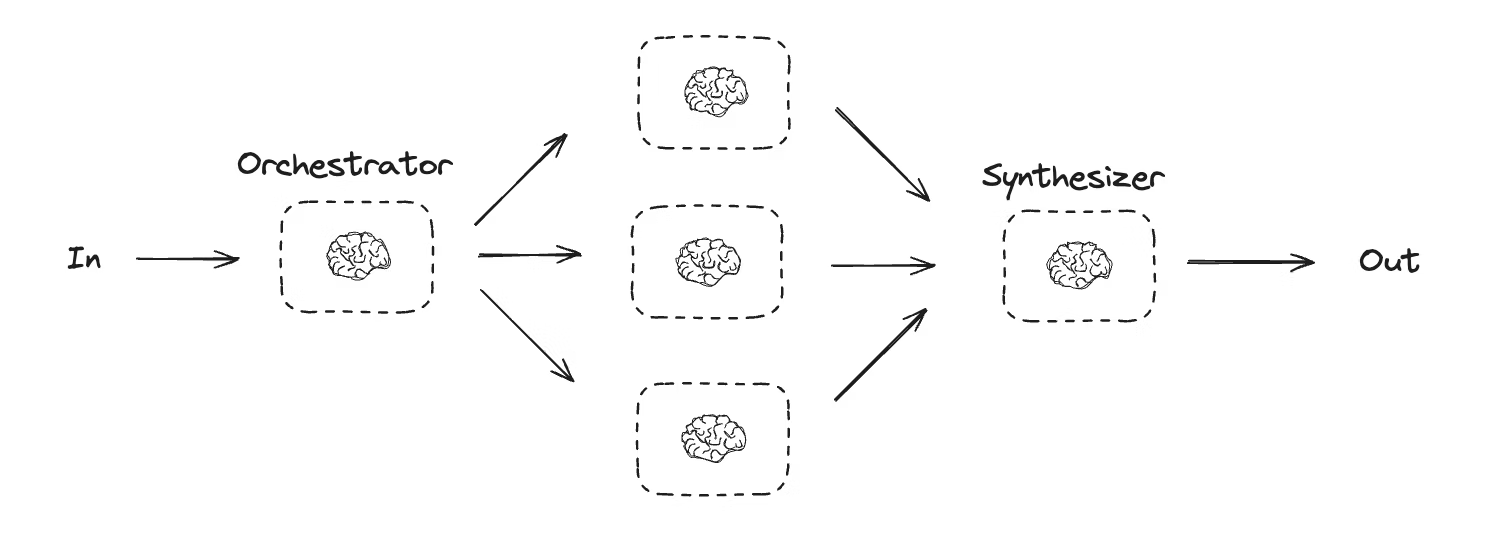






In [ ]:
from langgraph.types import Send
from langchain.messages import SystemMessage, ToolMessage, HumanMessage, AIMessage

In [ ]:
# STRUCTURED OUTPUT SCHEMA FOR ORCHESTRATOR

class ClassificationResult(BaseModel):
    """Router output - now supports MULTIPLE parallel tasks."""
    tasks: List[AgentTask] = Field(
        description="List of agents to invoke with their targeted queries"
    )
    requires_synthesis: bool = Field(
        default=False,
        description="Whether multiple agents are being used and synthesis is needed"
    )

In [ ]:
# WORKER/NODE STATE FOR INDIVIDUAL AGENTS

class AgentWorkerState(TypedDict):
    """State passed to each parallel worker."""
    task: AgentTask
    messages: List[AnyMessage]
    agent_results: Annotated[List[dict], operator.add]

### **Orchestrator / Router**

In [ ]:
# ROUTER

def classify_query_parallel(state: TravelPlannerState) -> dict:
    """
    Updated router that can dispatch to MULTIPLE agents.
    """
    router_llm = llm
    structured_llm = router_llm.with_structured_output(ClassificationResult)

    result = structured_llm.invoke([
        {
            "role": "system",
            "content": """ You are a Travel Request Router that can dispatch to MULTIPLE agents in parallel.

AVAILABLE AGENTS:
1. search_agent_node - Flight searches, hotel searches, pricing, availability
2. planner_agent_node - Itineraries, travel tips, weather, visas, activities, general guidance

ROUTING RULES:

SINGLE AGENT (requires_synthesis = false):
- Flight/hotel ONLY → search_agent_node
- Itinerary/planning ONLY → planner_agent_node
- General travel questions → planner_agent_node

MULTIPLE AGENTS (requires_synthesis = true):
- "Plan a trip AND find flights/hotels" → BOTH agents
- "Find hotels and create itinerary" → BOTH agents
- Requests mentioning BOTH booking AND planning → BOTH agents

When dispatching to BOTH agents:
1. Create a focused sub-query for each agent
2. search_agent_node query should focus on flights/hotels/pricing
3. planner_agent_node query should focus on itinerary/activities/tips

EXAMPLES:

Query: "Find flights from DEL to DXB"
→ tasks: [{"source": "search_agent_node", "user_query": "Find flights from DEL to DXB"}]
→ requires_synthesis: false

Query: "Plan a 5-day trip to Paris"
→ tasks: [{"source": "planner_agent_node", "user_query": "Plan a 5-day trip to Paris"}]
→ requires_synthesis: false

Query: "Plan a week in London and find me hotels under $200/night"
→ tasks: [
    {"source": "search_agent_node", "user_query": "Find hotels in London under $200/night for 1 week", "focus": "hotel search and pricing"},
    {"source": "planner_agent_node", "user_query": "Plan a week-long itinerary for London", "focus": "daily activities and attractions"}
  ]
→ requires_synthesis: true

Query: "I want to visit Tokyo - book flights from NYC and create a 5-day itinerary"
→ tasks: [
    {"source": "search_agent_node", "user_query": "Find flights from NYC to Tokyo", "focus": "flight options and prices"},
    {"source": "planner_agent_node", "user_query": "Create a 5-day itinerary for Tokyo", "focus": "daily schedule and activities"}
  ]
→ requires_synthesis: true """
        },
        {"role": "user", "content": state["user_query"]}
    ])

    return {
        "tasks": result.tasks,
        "requires_synthesis": result.requires_synthesis
    }


### **Dispatcher**

In [ ]:
# DISPATCHER (ROUTING FUNCTION RETURNS SEND OBJECTS EACH WITH ITS OWN STATE)

def dispatch_to_agents(state: TravelPlannerState):
    """
    Uses Send API to dispatch tasks to agents in PARALLEL.
    This is the key function that enables concurrent execution.
    """
    tasks = state.get("tasks", [])

    sends = []
    for task in tasks: # tasks = ["task 1", "task 2"]

        worker_state = {
              "messages": state.get("messages", []),
              "user_query": task.user_query,
              "tasks": state.get("tasks", []), # check
              "requires_synthesis": state.get("requires_synthesis", False),
              "agent_results": [],  # Each worker starts fresh
              "final_answer": "",
              "search_messages": [],  # Initialize empty for workers
              "planner_messages": [],  # Initialize empty for workers
        }

        if task.source == "search_agent_node":
            sends.append(Send("search_agent_node", worker_state))  # Your existing node
        elif task.source == "planner_agent_node":
            sends.append(Send("planner_agent_node", worker_state))  # Your existing node

    return sends

### **Synthesizer**

In [ ]:
# SYNTHESIZER

def synthesizer_node(state: TravelPlannerState) -> dict:
    """
    Combines results from parallel agents into a unified response.
    Only called when requires_synthesis is True.
    """

    agent_results = state.get("agent_results", [])


    if not agent_results:
        return {
            "final_answer": "I couldn't process your request.",
            "messages": [AIMessage(content="I couldn't process your request.")]
        }


    # If only one result, no synthesis needed
    if len(agent_results) == 1:
        result = agent_results[0]["result"]
        return {
            "final_answer": result,
            "messages": [AIMessage(content=result)]
        }

    # Format results for synthesis
    # **SEARCH_AGENT**
    #  Focus: flights
    #  (flight results here)

    #  ==================================================

    #  **PLANNER_AGENT**
    #  Focus: itinerary
    #  (itinerary here)
    results_formatted = "\n\n" + "="*50 + "\n\n".join([
        f"**{r['agent'].upper()}**\nFocus: {r.get('focus', 'N/A')}\n\n{r['result']}"
        for r in agent_results
    ])

    synthesis_prompt = """You are a Travel Response Synthesizer. Combine multiple agent outputs into
a single, well-organized, comprehensive response.

RULES:
1. Organize logically (e.g., Flights → Hotels → Itinerary → Tips)
2. Don't repeat information
3. Highlight key recommendations
4. Note any conflicts or alternatives
5. Create clear sections with headers
6. End with actionable next steps

Original Query: {query}

Agent Results:
{results}

Create a unified, helpful response:"""

    response = llm.invoke([
        HumanMessage(content=synthesis_prompt.format(
            query=state["user_query"],
            results=results_formatted
        ))
    ])

    return {
        "final_answer": response.content,
        "messages": [AIMessage(content=response.content)]
    }

## Define Search (Flight & Hotel) and Planner (TravelScout & ItineraryResearch) Nodes

### Augment the LLM with tools

In [ ]:
# Augment the LLM with tools
search_tools_by_name = {tool.name: tool for tool in search_tools}

search_model_with_tools = llm.bind_tools(search_tools)

In [ ]:
planner_tools = [internet_search, call_itinerary_research_agent]

planner_model_with_tools = llm.bind_tools(planner_tools)

### Search Agent & Tool Node

In [ ]:
def search_agent_node(state: TravelPlannerState):
    """Search agent with its own message history"""

    # Use search-specific messages
    search_msgs = state.get("search_messages", [])

    messages = [SystemMessage(content=flightHotelSearch_instructions)] + search_msgs

    # If this is first call, add the user query
    if not search_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = search_model_with_tools.invoke(messages)

    return {
        "search_messages": [response], #use that reducer operator.add
        "agent_results": [{
            "agent": "search_agent",
            "focus": "flights and hotels",
            "result": response.content # llm responding
        }] if not response.tool_calls else []
    }

In [ ]:
def search_tool_node(state: TravelPlannerState): #ToolNode()
    """Execute search tools"""
    search_msgs = state.get("search_messages", [])

    # Check if search_messages exists and has content
    if not search_msgs:
        return {"search_messages": []}

    last_message = search_msgs[-1]

    # Check if last_message has tool_calls
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"search_messages": []}

    result = []
    for tool_call in last_message.tool_calls:
        tool = search_tools_by_name.get(tool_call["name"]) #CHANGE???
        if tool:
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    return {"search_messages": result}

### Planner Agent & Tool Node

In [ ]:
def planner_agent_node(state: TravelPlannerState):
    """Planner agent with its own message history"""

    # Use planner-specific messages
    planner_msgs = state.get("planner_messages", [])

    messages = [SystemMessage(content=travel_scout_instructions)] + planner_msgs

    # If this is first call, add the user query
    if not planner_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = planner_model_with_tools.invoke(messages)

    return {
        "planner_messages": [response],
        "agent_results": [{
            "agent": "planner_agent",
            "focus": "travel planning and itinerary",
            "result": response.content
        }] if not response.tool_calls else []
    }

In [ ]:
def planner_tool_node(state: TravelPlannerState): #ToolNode()
    """Execute planner tools"""
    planner_msgs = state.get("planner_messages", [])

    # Check if planner_messages exists and has content
    if not planner_msgs:
        return {"planner_messages": []}

    last_message = planner_msgs[-1]

    # Check if last_message has tool_calls
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"planner_messages": []}

    planner_tools_by_name = {tool.name: tool for tool in planner_tools}
    result = []

    for tool_call in last_message.tool_calls:
        tool = planner_tools_by_name.get(tool_call["name"])
        if tool:
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    return {"planner_messages": result}

### Conditional Edges

In [ ]:
def should_continue_for_searchAgent(state: TravelPlannerState):
    search_msgs = state.get("search_messages", [])
    if search_msgs and hasattr(search_msgs[-1], 'tool_calls') and search_msgs[-1].tool_calls:
        return "search_tool_node"
    return "synthesizer"

In [ ]:
def should_continue_for_plannerAgent(state: TravelPlannerState):
    """Check if planner needs to continue tool loop"""
    planner_msgs = state.get("planner_messages", [])
    if planner_msgs and hasattr(planner_msgs[-1], 'tool_calls') and planner_msgs[-1].tool_calls:
        return "planner_tool_node"
    return "synthesizer"

# **Step 6 - Build & Compile Your Workflow**

In [ ]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

In [ ]:
def build_parallel_travel_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(TravelPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("search_agent_node", search_agent_node)
    builder.add_node("planner_agent_node", planner_agent_node)
    builder.add_node("search_tool_node", search_tool_node)
    builder.add_node("planner_tool_node", planner_tool_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents, #dispatcher
        ["search_agent_node", "planner_agent_node"]
    )

    # Search agent tool loop
    builder.add_conditional_edges(
        "search_agent_node",
        should_continue_for_searchAgent,
        ["search_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("search_tool_node", "search_agent_node")

    # Planner agent tool loop
    builder.add_conditional_edges(
        "planner_agent_node",
        should_continue_for_plannerAgent,
        ["planner_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("planner_tool_node", "planner_agent_node")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    return builder.compile()

In [ ]:
# Compile the agent
agent = build_parallel_travel_agent()

In [ ]:
# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

# **Step 7 - Test the Multi-Agent System**

1.   List item
2.   List item




### Test Multi-Agent Travel Planner

In [ ]:
result = agent.invoke({
        "user_query": "Plan a 5-day trip to Paris and find me flights from JFK to LHR for 1 adult only on 21 Jan 2026 (one way trip) & also let me know hotels for myself only (adult) from my lading to LHR to next day",
        "messages": []
    })

In [ ]:
# Print everything step by step
print("=" * 60)
print("USER QUERY:")
print(result["user_query"])

print("\n" + "=" * 60)
print("TASKS DISPATCHED:")
for task in result.get("tasks", []):
    print(f"  • {task.source}: {task.user_query}")

print("\n" + "=" * 60)
print("AGENT RESULTS:")
for r in result.get("agent_results", []):
    print(f"\n[{r['agent'].upper()}]")
    print("-" * 40)
    print(r["result"][:50000] + "..." if len(r["result"]) > 500 else r["result"])

print("\n" + "=" * 60)
print("FINAL SYNTHESIZED RESPONSE:")
print("=" * 60)
print(result["final_answer"])

# **Add Persistence**

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

In [ ]:
def build_parallel_travel_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(TravelPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("search_agent_node", search_agent_node)
    builder.add_node("planner_agent_node", planner_agent_node)
    builder.add_node("search_tool_node", search_tool_node)
    builder.add_node("planner_tool_node", planner_tool_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents,
        ["search_agent_node", "planner_agent_node"]
    )

    # Search agent tool loop
    builder.add_conditional_edges(
        "search_agent_node",
        should_continue_for_searchAgent,
        ["search_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("search_tool_node", "search_agent_node")

    # Planner agent tool loop
    builder.add_conditional_edges(
        "planner_agent_node",
        should_continue_for_plannerAgent,
        ["planner_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("planner_tool_node", "planner_agent_node")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    # Built-in Persistence
    checkpointer = InMemorySaver()

    return builder.compile(checkpointer=checkpointer)

In [ ]:
# Compile the agent
agent = build_parallel_travel_agent()

In [ ]:
config = {"configurable": {"thread_id": "samwel"}}
config2 = {"configurable": {"thread_id": "jay"}}

In [ ]:
result = agent.invoke(
    {
        "user_query": "What is the best time to visit Jaipur?",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

## Best time to visit Jaipur (weather + vibes)

### Peak season (best overall): **November to March**
- **Why:** Cool, dry, and most comfortable for forts, palaces, and bazaars.
- **Typical temps:** roughly **8–32°C** (nights can feel chilly).
- **Trade-offs:** busiest months; prices and crowds tend to be highest.

### Shoulder season (good value): **late September–October** and **March**
- **Why:** Generally pleasant (especially mornings/evenings), fewer crowds than mid-winter.
- **Bonus:** Often lines up with major festive atmosphere (see below).
- **Watch-outs:** March starts warming up quickly.

### Off season (least comfortable): **April to June**
- **Why to avoid:** Very hot; outdoor sightseeing can be draining.
- **If you must go:** Do early mornings, indoor attractions mid-day, and hydrate aggressively.

### Monsoon (mixed but can be nice): **July to September**
- **Why consider:** Fewer tourists; the city and surrounding landscapes can look fresher.
- **Watch-outs:** humidity 

In [ ]:
result = agent.invoke(
    {
        "user_query": "Major historical sites there (must visit kind of)",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

## Quick Clarification (so I don’t guess wrong)
Your agents referenced **Jaipur**, so I’m assuming “there” = **Jaipur, Rajasthan (India)**. If you meant a different destination, tell me the city/region and how many days you have, and I’ll reprioritize the list.

---

## Must-Visit Historical Sites in Jaipur (Major “Don’t Miss”)
### 1) **Amber Fort (Amer Fort)**
**Why it’s essential:** Jaipur’s most iconic hill fort—grand courtyards, gates, mirror-work rooms, and sweeping views.  
**Best time:** Go **early morning** for cooler temps and fewer crowds (especially Oct–Mar).

### 2) **City Palace**
**Why it’s essential:** The royal residence complex in the old city—architecture, courtyards, museums, and the “living history” of Jaipur’s rulers.  
**Best time:** Morning for more comfortable walking and better photos.

### 3) **Hawa Mahal (Palace of Winds)**
**Why it’s essential:** One of Jaipur’s signature façades; historically designed for royal women to observe street life unseen.  
**Pro t

In [ ]:
result = agent.invoke(
    {
        "user_query": "What all cities I can cover along with this tour (in nearby which should not take more than 2-3 days extra)",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config2
)

print(result['final_answer'])

I can help, but I need a bit more detail about “this tour” to recommend add-on cities that fit into just +2–3 days.

## Quick questions (reply with whatever you know)
1. **What is the base tour itinerary?** (cities/places included, in order)
2. **Total duration** of the tour (how many days/nights) and **how many days you can add** (2 or 3).
3. **Dates/season** (or at least the month)—this affects road/train times and what’s worth adding.
4. **Start & end points** (where you arrive and depart from).
5. **Your travel style**: fast-paced or relaxed? prefer **big cities / nature / history / beaches / food / shopping**?
6. **Transport preference**: day trips only, or okay with 1–2 overnights? train/car/flight?

## How I’ll choose the best “nearby” add-ons (once I have your tour)
For +2–3 days, the best options are usually:
- **1 nearby city with 2 nights** (most comfortable), or  
- **2 close places with 1 night each** (more rushed), or  
- **Day trips from a base city** (no hotel changes)
